# Wstęp
Laboratorium 5 stanowi wprowadzenie w tematykę sieci konwolucyjnych. Sieci te wykorzystują, jak sama nazwa wskazuje, operację konwolucji (splotu) co pozwala na uwzględnienie informacji o lokalnym sąsiedztwie przestrzennym w przetwarzanych danych. W przypadku obrazów, jest to sąsiedztwo pikseli w dwuwymiarowej przestrzeni obrazu.

# Cel  ćwiczenia

Celem ćwiczenia jest zapoznianie z:

*   operacją konwolucji 2D i jej implementacją w torchu
*   warstwami konwolucyjnymi i ich parametrami
*   operacjami poolingu
*   prostymi sieciami konwolucyjnymi w klasyfikacji obrazu

# Konwolucja 2D

Najpierw wprowadzimy operację konwolucji. Konwolucja 2D przyjmuje na wejściu tensory o kształcie `(B,C,H,W)` - batch, channel, width, height. Kanały nazywamy też *mapami cech*, jako że w warstwach innych niż wejściowa są to w dalszym ciągu dwuwymiarowe "obrazki", ale odpowiadające już nie wprost kanałom RGB, ale pewnym cechom wydobywanym z mapy cech na wejściu przez uczące się filtry.

Tensor filtrów ma wymiary `(I,O,H,W)` - liczba kanałów warstwy wejściowej, liczba kanałów warstwy wyjściowej, wysokość i szerokość filtra. Możemy pomyśleć o tym przez analogię z warstwą w pełni połączoną: tam, element tensora wag `weights[i,j]` był jedną liczbą i odpowiadał połączeniu i-tego wejścia do j-tego wyjścia. W konwolucji, `weights[i,j]`  będzie odpowiadać połączeniu i-tej mapy cech do j-tej mapy cech, będzie jednak całą macierzą, ponieważ dla każdego połączenia we-wy map cech uczymy dwuwymiarowego filtra.

Dla przykładu, zaimplementujmy filtr rozmywający obraz RGB - każdy kanał z osobna. Filtr rozmywający jeden kanał definiuje `filter`, a ponieważ chcemy uzyskać połączenie tylko kanałów wejściowych do wyjściowych: R do R, G do G, B do B, a ponieważ dla każdego z tych połączeń filtr będzie taki sam, możemy po prostu wymnożyć go przez tensor `(3,3,1,1)`, utworzony z macierzy jednostkowej. W torchu taką macierz zwraca metoda `eye`.

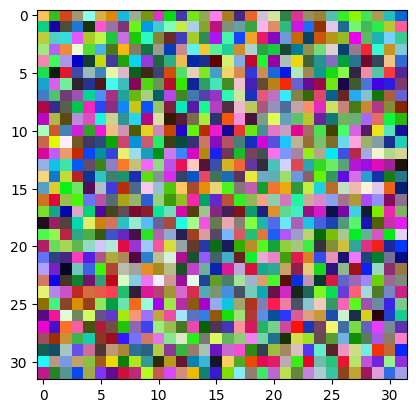

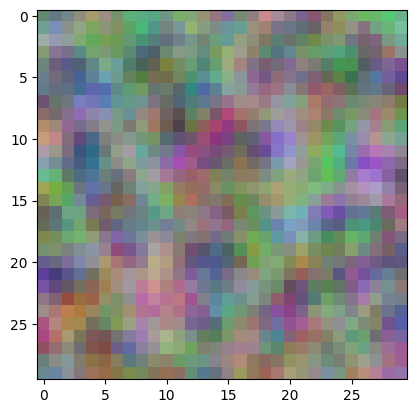

In [2]:
import torch
from matplotlib import pyplot as plt

tensor = torch.rand((1,3,32,32))

channel_connections = torch.eye(3)

filter = torch.tensor(
    [[0.1,0.1,0.1],
    [0.1,0.2,0.1],
    [0.1,0.1,0.1]]
)

blur = channel_connections.view(3,3,1,1)*filter

plt.imshow(tensor[0].permute(1,2,0))
plt.show()

blurred = torch.nn.functional.conv2d(tensor,blur)

plt.imshow(blurred[0].permute(1,2,0))
plt.show()


# Zadanie 1

Zdefiniuj tensor 3x3x3x3 `rg_blur_to_b`.

Zakładając że mamy do czynienia z obrazem RGB, konwolucja na wyjściu zwracać ma obraz RGB, gdzie

* w kanale B zwracamy uśrednienie rozmytych (analogiczne jak wyżej) kanałów R, G obrazka wejściowego
* kanały R i G na wyjściu są zerami


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.0..0.999354].


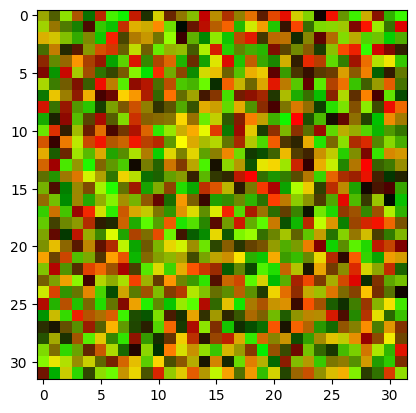

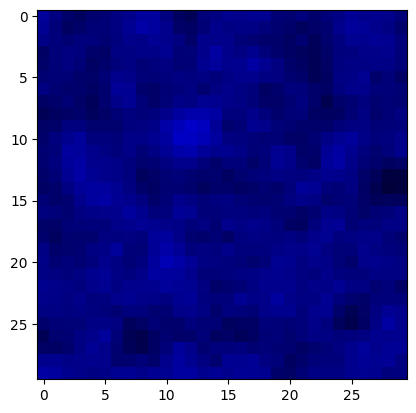

In [3]:
tensor = torch.rand((10,3,32,32))
tensor[:,2] = -7

filter = torch.tensor(
    [[0.1,0.1,0.1],
    [0.1,0.2,0.1],
    [0.1,0.1,0.1]]
)

channel_connections = torch.tensor(
    [[0,0,0],
    [0,0,0],
    [0.5,0.5,0]]
)

rg_blur_to_b = channel_connections.view(3,3,1,1)*filter

blurred = torch.nn.functional.conv2d(tensor,rg_blur_to_b)

plt.imshow(tensor[0].permute(1,2,0))
plt.show()

plt.imshow(blurred[0].permute(1,2,0))
plt.show()



# Warstwa konwolucyjna

W sieci konwolucyjnej będziemy wykorzystywać operację konwolucji tak jak opisane powyżej, w której uczone są tensor filtrów i bias dodawany do tensora na wyjściu. Warstwę z uczonymi parametrami definiuje klasa:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Pokrótce wyjaśnijmy parametry tej klasy na przykładzie filtra 2x2.

Poniższy obrazek reprezentuje lewy, górny róg mapy cech:

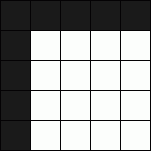

Na czerwono zaznaczymy pierwszy krok filtra przechodzącego po obrazie, na niebiesko drugi. Kolor fioletowy oznaczać będzie, że pola obejmowane przez filtry się pokrywają. Oznaczone pola przekładają się na dwa pierwsze piksele w wyjściowej mapie cech. Filtr 2x2 przy domyślnych parametrach będzie przechodził po obrazie następująco:

--------- Wejście ---------------------  Wyjście ----------

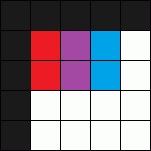
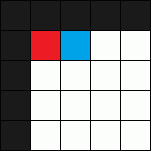


W kodzie deklarujemy w pierwszych trzech argumentach konstruktora `torch.nn.Conv2d`: liczbę kanałów wejściowych, liczbę kanałów wyjściowych, rozmiar filtra. Przy okazji, torchowa konwencja - aby podać rozmiar okna 2d możemy użyć jako argumentu zarówno krotki (x,y) jak i jednej liczby całkowitej, definiującej okno kwadratowe (x,x).

In [4]:
data_batch = torch.zeros(10,16,32,32)

#deklaracja warstwy: 16 kanałów wejściowych, 32 wyjściowych, filtr 2x2
conv_layer = torch.nn.Conv2d(16,32,2)

conv_layer(data_batch).shape

torch.Size([10, 32, 31, 31])

Jak widać, w wymiarach szerokości i wysokości, mapy cech zmniejszają się o 1.

Parametr `padding` pozwala na dodanie dodatkowych pikseli na krawędzi obrazka. Używany jest, aby zachować stałą szerokość i wysokość mapy cech po konwolucji. Dla `padding=1` pola obejmowane przez filtr będą wyglądać tak:

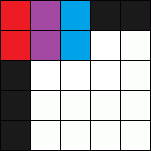

In [5]:
data_batch = torch.zeros(10,16,32,32)

conv_layer = torch.nn.Conv2d(16,16,2,padding=1)
print(conv_layer(data_batch).shape)

conv_layer = torch.nn.Conv2d(16,16,3,padding=1)
print(conv_layer(data_batch).shape)

torch.Size([10, 16, 33, 33])
torch.Size([10, 16, 32, 32])


Zauważ, że ze względu na symetryczny padding (dodawanie pikseli po obu stronach obrazu wejściowego) operacja zachowuje wysokość i szerokość tylko dla filtra o nieparzystym rozmiarze.

Parametr `stride` to krok filtra. Używany jest aby zredukować wymiary szerokości i wysokości pomiędzy kolejnymi warstwami konwolucyjnymi. `stride=2` daje nam downsampling do dwukrotnie mniejszej rozdzielczości, z wykorzystaniem uczącej się warstwy która może jednocześnie zmienić liczbę kanałów:

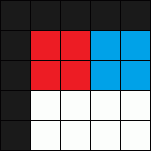


In [6]:
data_batch = torch.zeros(10,16,32,32)
conv_layer = torch.nn.Conv2d(16,16,2,stride=2)

conv_layer(data_batch).shape

torch.Size([10, 16, 16, 16])

Parametr `dilation` określa rozstaw filtra. Pozwala to obejmować filtrem piksele odległe od siebie o pewną stałą wartość. Szczególnie istotnym wykorzystaniem tego parametru jest użycie sekwencji warstw, w których kolejne wartości `dilation` to kolejne potęgi 2 - efektywnie skalując rozmiar pola obejmowanego przez całą architekturę wykładniczo z głębokością. Dla `dilation=2`:

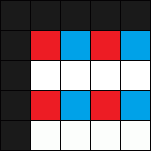

In [7]:
data_batch = torch.zeros(10,16,32,32)
conv_layer = torch.nn.Conv2d(16,16,2,dilation=2)

conv_layer(data_batch).shape

torch.Size([10, 16, 30, 30])

# Pooling

Zanim z warstw zbudujemy sieć, warto jeszcze wprowadzić operacje: poolingu i spłaszczania.

In [8]:
pool_layer =  torch.nn.MaxPool2d(2) #okno o stałym rozmiarze 2x2
adaptive_pool_layer = torch.nn.AdaptiveAvgPool2d((2,4)) #pooling adaptacyny
flatten_layer = torch.nn.Flatten()

data_batch = torch.zeros(10,3,128,128)
pool_layer(data_batch).shape, adaptive_pool_layer(data_batch).shape, flatten_layer(data_batch).shape

(torch.Size([10, 3, 64, 64]),
 torch.Size([10, 3, 2, 4]),
 torch.Size([10, 49152]))

Dwa standardowe typy poolingu to Max i Average pooling - zwracające odpowiednio maximum lub średnią z okna pooling.

Pooling o stałym rozmiarze okna pozwala nam na downsampling w wymiarach szerokości i wysokości bez potrzeby dodawania uczącej się warstwy. Przykładowo, okno 2x2 da nam redukcję szerokości i wysokości o dwa razy.

Pooling o adaptacyjnym rozmiarze okna pozwala na sprowadzenie wyniku konwolucji do stałego, zadanego rozmiaru wysokość/szerokość, co jest szczególnie przydatne jeśli chcemy przetwarzać obrazy o różnych rozmiarach. Zwykle wykorzystuje się go tylko w jednym miejscu, przed spłaszczeniem i ostatnią warstwą w pełni połączoną. Adaptacyjna warstwa poolingu z parametrem 2 bedzie redukować rozmiar w wymiarach wysokość, szerokośc do 2 na 2 - samodzielnie wyliczając dla każdego wejścia rozmiar okna potrzebny, żeby takie wyjście uzyskać.

Spłaszczanie zaś, jak sama nazwa wskazuje spłaszcza kształt tensora z (B, C, H, W) do (B, C\*H\*W)





Aby przejść do budowania i uczenia sieci konwolucyjnych, wczytamy zbiór CIFAR10. Zdefiniujemy też funkcje wykorzystane już na poprzednich laboratoriach:

In [9]:
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple
from tqdm import tqdm

device = torch.device("cpu")

transform = torchvision.transforms.ToTensor()

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch.to(device))
        all += len(y_pred)
        loss += loss_fn(y_pred, y_batch.to(device)).sum()
        correct += count_correct(y_pred, y_batch.to(device))
    return loss / all, correct / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: str = True
):
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in tqdm(train_dl):
            y_pred = model(X_batch.to(device))
            loss = loss_fn(y_pred, y_batch.to(device))
            loss.backward()
            optimiser.step()
            optimiser.zero_grad()

        model.eval()
        with torch.no_grad():
            train_loss, train_acc = validate(
                model=model, loss_fn=loss_fn, dataloader=train_dl
            )
            val_loss, val_acc = validate(
                model=model, loss_fn=loss_fn, dataloader=val_dl
            )
            train_losses.append(train_loss.item())
            train_accs.append(train_acc.item())
            val_accs.append(val_acc.item())
            val_losses.append(val_loss.item())
        
            
            if print_metrics:
                print(
                    f"Epoch {epoch}: "
                    f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                    f"validation loss = {val_loss:.3f} (acc: {val_acc:.3f})"
                )
    
    return train_losses, train_accs, val_losses, val_accs

/Users/mikolajolesinski/Desktop/glebokie_sieci_neuronowe/listy/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Zdefiniujmy teraz prostą sieć konwolucyjną.

# Zadanie 2

Uzupełnij kod klasy `SimpleCNN` tak, aby warstwy konwolucyjne nie zmieniały szerokości i wysokości mapy cech na wyjściu oraz aby wyjście w postaci tensora miało kształt zgodny z pożądanym `(batch_size, labels)`. Użyj rozmiaru filtra 3x3.

Zauważ, że o ile warstwy konwolucyjne nie muszą znać rozmiaru obrazu, o tyle spłaszczenie obrazu i podanie do warstwy w pełni połączonej wymusza na nas zdefiniowanie tego rozmiaru z góry. Sieć zbudowana w ten sposób przetwarzać będzie tylko obrazy o stałej szerokości i wysokości. Na potrzeby zadania, sieć ma być dostosowana do zbioru CIFAR: przyjmować obrazy RGB, 32x32 na wejściu i zwracać 10-elementowy wektor na wyjściu.

In [10]:
class SimpleCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("conv_1", torch.nn.Conv2d(3, channels, 3, padding=1))
    self.model.add_module("relu_1", torch.nn.ReLU())
    self.model.add_module("max_pool", torch.nn.MaxPool2d(2))
    self.model.add_module("conv_2"  , torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_2", torch.nn.ReLU())
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", torch.nn.Linear(16 * 16 * channels, labels))
    
  def forward(self, x):
    return self.model(x)

Zweryfikuj, że sieć zwraca wlaściwy wymiar wyjścia i zmierz czas przetwarzania konwolucji na CPU i GPU

In [11]:
cnn_model = SimpleCNN(16, 10)
out = cnn_model(torch.zeros(128,3,32,32))
assert out.shape==(128,10)

%timeit cnn_model(torch.zeros(128,3,32,32))
%timeit cnn_model(torch.zeros(128,3,32,32))
# cnn_model.cuda()
# %timeit cnn_model(torch.zeros(128,3,32,32).cuda())


8.88 ms ± 1.92 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
7.85 ms ± 1.27 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


Sprawdźmy, że jesteśmy w stanie uczyć tę sieć:

In [12]:
optimizer = optim.Adam(cnn_model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()
fit(cnn_model, optimizer, loss_fn, train_dl, test_dl, 5, True)

  0%|          | 0/1563 [00:00<?, ?it/s]/Users/mikolajolesinski/Desktop/glebokie_sieci_neuronowe/listy/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 1563/1563 [00:14<00:00, 109.89it/s]


Epoch 0: train loss = 0.038 (acc: 0.576), validation loss = 0.039 (acc: 0.560)


100%|██████████| 1563/1563 [00:16<00:00, 97.03it/s] 


Epoch 1: train loss = 0.035 (acc: 0.610), validation loss = 0.037 (acc: 0.588)


100%|██████████| 1563/1563 [00:14<00:00, 109.36it/s]


...

100%|██████████| 1563/1563 [00:14<00:00, 111.55it/s]


Epoch 3: train loss = 0.031 (acc: 0.660), validation loss = 0.034 (acc: 0.623)


100%|██████████| 1563/1563 [00:14<00:00, 105.22it/s]


Epoch 4: train loss = 0.029 (acc: 0.684), validation loss = 0.033 (acc: 0.634)


([0.0378139354288578,
  0.03503911942243576,
  0.031574979424476624,
  0.030640801414847374,
  0.02886669896543026],
 [0.5764999985694885,
  0.6104000210762024,
  0.6504200100898743,
  0.6604400277137756,
  0.6842399835586548],
 [0.038808517158031464,
  0.03689417988061905,
  0.034222204238176346,
  0.034252069890499115,
  0.03323744237422943],
 [0.5595999956130981,
  0.5881999731063843,
  0.6133000254631042,
  0.6226999759674072,
  0.6335999965667725])

# Zadanie 3

Zdefiniuj klasę `CNN`, sieć o strukturze

*   warstwa wejściowa in_conv o rozmiarze filtra 1x1 (transformuje liczbę kanałów z 3 na docelową)
*   sekwencja warstw konwolucyjnych z downsamplingiem 2x w wymiarach przestrzennych w każdej warstwie (patrz niżej)
*   spłaszczenie wyniku do wektora
*   warstwa w pełni połączona

Klasa powinna być parametryzowalna tak, aby

*   umożliwić wybór rozmiaru filtra w warstwach konwolucji oprócz in_conv
*   umożliwić wybór zarówno liczby warstw, jak i liczby kanałów w poszczególnych warstwach konwolucyjnych
*   umożliwić wybór między downsamplingiem poprzez dodanie warstw poolingu po każdej warstwie, a poprzez ustawienie paramteru stride (zachowujemy **tę samą liczbę warstw konwolucyjnych**, warstwa in_conv nie dokonuje downsamplingu)




In [13]:
class CNN(torch.nn.Module):
    def __init__(self, kernel_size: int, channels: list, use_pooling: bool, labels: int):
        super().__init__()
        self.model = torch.nn.Sequential()
        self.model.add_module("in_conv", torch.nn.Conv2d(3, channels[0], 1))
        
        for i, (in_ch, out_ch) in enumerate(zip(channels[:-1], channels[1:])):
            if use_pooling:
                self.model.add_module(f"conv_{i}", torch.nn.Conv2d(in_ch, out_ch, kernel_size, padding=kernel_size//2))
                self.model.add_module(f"relu_{i}", torch.nn.ReLU())
                self.model.add_module(f"pool_{i}", torch.nn.MaxPool2d(2))
            else:
                self.model.add_module(f"conv_{i}", torch.nn.Conv2d(in_ch, out_ch, kernel_size, stride=2, padding=kernel_size//2))
                self.model.add_module(f"relu_{i}", torch.nn.ReLU())
        
        n_layers = len(channels) - 1
        spatial = 32 // (2 ** n_layers)
        self.model.add_module("flatten", torch.nn.Flatten())
        self.model.add_module("linear", torch.nn.Linear(channels[-1] * spatial * spatial, labels))

    def forward(self, x):
        return self.model(x)

Zweryfikuj działanie implementacji:

In [14]:
dummy_data = torch.zeros(37,3,32,32)

# utwórz CNN z: 15 etykietami wyjściowymi, filtrem 5x5, 3 warstwy conv z liczbą kanałów: 16,32,64, downsampling warstwą konwolucyjną
cnn_model = CNN(kernel_size=5, channels=[16,32,64], use_pooling=False, labels=15)

assert cnn_model(dummy_data).shape == (37,15)

# utwórz CNN: 10 etykiet wyjściowych, filtr 3x3, 4 warstwy conv z liczbą kanałów: 8,16,32,64, downsampling warstwą poolingu
cnn_model = CNN(kernel_size=3, channels=[8,16,32,64], use_pooling=True, labels=10)
assert cnn_model(dummy_data).shape == (37,10)

%timeit cnn_model(torch.zeros(128,3,32,32))
#cnn_model.cuda()
#%timeit cnn_model(torch.zeros(128,3,32,32).cuda())

20.1 ms ± 4.77 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Zadanie 4

Wykorzystaj zdefiniowaną klasę, aby przeprowadzić porównania:

1.   Uczenie z filtrem 3x3 a 5x5
2.   Uczenie z Max Pooling a warstwą konwolucyjną do downsamplingu
3.   Uczenie z trzema warstwami o rozmiarach 16,32,64, a uczenie z trzema warstwami o rozmiarach 32,32,32

Porównaj w kontekście metryki F-score, wyrysuj krzywe uczenia. Możesz tu korzystać z kodu napisanego na poprzednich laboratoriach. Przy problemach z mocą obliczeniową, dokonaj trenowania na mniejszym podzbiorze zbioru treningowego (np. 10%).

=== 3x3 vs 5x5 ===


100%|██████████| 1563/1563 [00:21<00:00, 73.57it/s]


Epoch 0: train loss = 0.045 (acc: 0.490), validation loss = 0.045 (acc: 0.485)


100%|██████████| 1563/1563 [00:22<00:00, 68.02it/s]


Epoch 1: train loss = 0.039 (acc: 0.563), validation loss = 0.040 (acc: 0.543)


...

Epoch 7: train loss = 0.028 (acc: 0.683), validation loss = 0.033 (acc: 0.637)


100%|██████████| 1563/1563 [00:40<00:00, 38.84it/s]


Epoch 8: train loss = 0.028 (acc: 0.681), validation loss = 0.033 (acc: 0.632)


100%|██████████| 1563/1563 [00:38<00:00, 40.25it/s]


Epoch 9: train loss = 0.027 (acc: 0.696), validation loss = 0.033 (acc: 0.637)


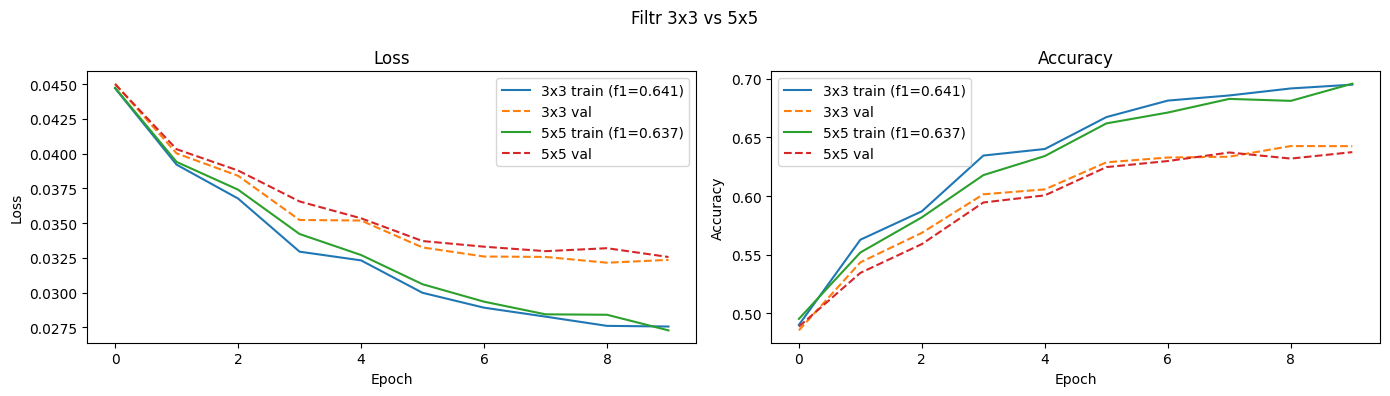

=== Pooling vs Stride ===


  0%|          | 0/1563 [00:00<?, ?it/s]/Users/mikolajolesinski/Desktop/glebokie_sieci_neuronowe/listy/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 1563/1563 [00:26<00:00, 59.81it/s]


Epoch 0: train loss = 0.039 (acc: 0.558), validation loss = 0.040 (acc: 0.542)


100%|██████████| 1563/1563 [00:24<00:00, 64.88it/s]


Epoch 1: train loss = 0.035 (acc: 0.618), validation loss = 0.036 (acc: 0.592)


...

Epoch 7: train loss = 0.027 (acc: 0.697), validation loss = 0.034 (acc: 0.627)


100%|██████████| 1563/1563 [00:13<00:00, 117.55it/s]


Epoch 8: train loss = 0.026 (acc: 0.709), validation loss = 0.034 (acc: 0.633)


100%|██████████| 1563/1563 [00:13<00:00, 118.24it/s]


Epoch 9: train loss = 0.026 (acc: 0.714), validation loss = 0.034 (acc: 0.633)


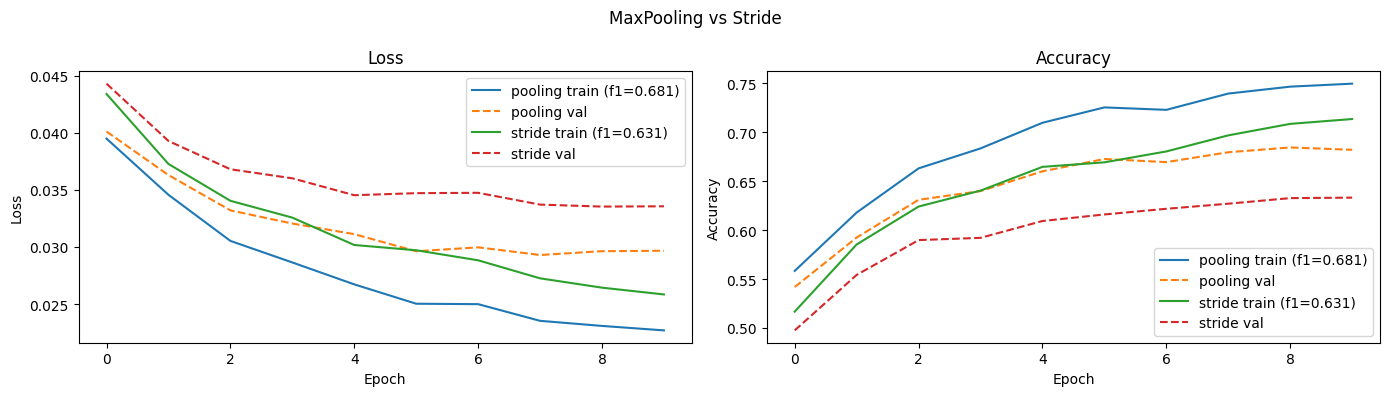

=== [16,32,64] vs [32,32,32] ===


  0%|          | 0/1563 [00:00<?, ?it/s]/Users/mikolajolesinski/Desktop/glebokie_sieci_neuronowe/listy/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 1563/1563 [00:43<00:00, 36.17it/s]


Epoch 0: train loss = 0.036 (acc: 0.590), validation loss = 0.037 (acc: 0.573)


100%|██████████| 1563/1563 [00:49<00:00, 31.30it/s]


Epoch 1: train loss = 0.029 (acc: 0.681), validation loss = 0.031 (acc: 0.652)


...

Epoch 7: train loss = 0.022 (acc: 0.761), validation loss = 0.028 (acc: 0.693)


100%|██████████| 1563/1563 [01:03<00:00, 24.68it/s]


Epoch 8: train loss = 0.021 (acc: 0.764), validation loss = 0.029 (acc: 0.687)


100%|██████████| 1563/1563 [01:01<00:00, 25.60it/s]


Epoch 9: train loss = 0.021 (acc: 0.771), validation loss = 0.029 (acc: 0.691)


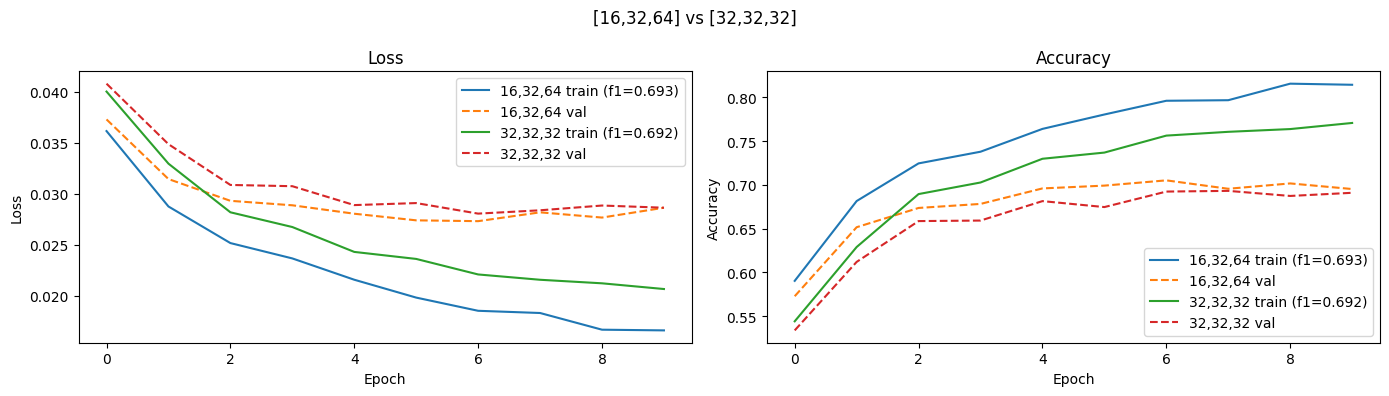

In [17]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

def evaluate_f1(model, dataloader):
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            y_pred = model(X_batch.to(device))
            preds = torch.argmax(y_pred, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return f1_score(all_labels, all_preds, average='macro')

def fit_and_track(model, epochs=10):
    optimizer = optim.Adam(model.parameters())
    loss_fn = torch.nn.CrossEntropyLoss()
    model.to(device)

    train_losses, train_accs, val_losses, val_accs = fit(
        model=model,
        optimiser=optimizer,
        loss_fn=loss_fn,
        train_dl=train_dl,
        val_dl=test_dl,
        epochs=epochs,
        print_metrics=True
    )

    f1 = evaluate_f1(model, test_dl)
    return train_losses, train_accs, val_losses, val_accs, f1

def plot_comparison(results: dict, title: str):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    for name, (train_losses, train_accs, val_losses, val_accs, f1) in results.items():
        ax1.plot(train_losses, label=f"{name} train (f1={f1:.3f})")
        ax1.plot(val_losses,   label=f"{name} val", linestyle="--")
        ax2.plot(train_accs,   label=f"{name} train (f1={f1:.3f})")
        ax2.plot(val_accs,     label=f"{name} val", linestyle="--")

    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

EPOCHS = 10

# 1. Filtr 3x3 vs 5x5
print("=== 3x3 vs 5x5 ===")
results_1 = {}
results_1["3x3"] = fit_and_track(CNN(kernel_size=3, channels=[8, 16, 32], use_pooling=True, labels=10), EPOCHS)
results_1["5x5"] = fit_and_track(CNN(kernel_size=5, channels=[8, 16, 32], use_pooling=True, labels=10), EPOCHS)
plot_comparison(results_1, "Filtr 3x3 vs 5x5")

# 2. MaxPooling vs stride
print("=== Pooling vs Stride ===")
results_2 = {}
results_2["pooling"] = fit_and_track(CNN(kernel_size=3, channels=[8, 16, 32], use_pooling=True,  labels=10), EPOCHS)
results_2["stride"]  = fit_and_track(CNN(kernel_size=3, channels=[8, 16, 32], use_pooling=False, labels=10), EPOCHS)
plot_comparison(results_2, "MaxPooling vs Stride")

# 3. [16,32,64] vs [32,32,32]
print("=== [16,32,64] vs [32,32,32] ===")
results_3 = {}
results_3["16,32,64"] = fit_and_track(CNN(kernel_size=3, channels=[16, 32, 64], use_pooling=True, labels=10), EPOCHS)
results_3["32,32,32"] = fit_and_track(CNN(kernel_size=3, channels=[32, 32, 32], use_pooling=True, labels=10), EPOCHS)
plot_comparison(results_3, "[16,32,64] vs [32,32,32]")